In [50]:
# ============================================
# A) IMPORTS + FORCE CPU (NO MPS)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = "cpu"
print("Using device:", device)


FORCED DEVICE: cpu


In [84]:
# ============================================
# B) REALISTIC WORLD SIMULATOR
# ============================================

def simulate_realistic_world(n=10000):
    race = np.random.choice([0,1,2], n, p=[0.6,0.25,0.15])
    gender = np.random.choice([0,1], n)
    age = np.clip(np.random.normal(50,12,n), 18, 90)

    ses = (
        0.4*(race==0)
        + 0.0*(race==1)
        - 0.4*(race==2)
    ) + np.random.normal(0,0.4,n)

    lifestyle = (
        0.5*ses
        - 0.015*(age-50)
        + np.random.normal(0,0.4,n)
    )

    bmi = (
        26
        - 1.2*lifestyle
        + 1.0*(gender==1)
        + np.random.normal(0,3,n)
    )

    glucose_true = (
        95
        + 0.9*(bmi-26)
        - 2.0*lifestyle
        + 0.3*((age-50)/10)
        + np.random.normal(0,8,n)
    )

    hba1c_true = (
        5.4
        + 0.09*(bmi-26)
        - 0.1*lifestyle
        + 0.04*((age-50)/10)
        + np.random.normal(0,0.3,n)
    )

    logit = -7 + 0.05*glucose_true + 1.0*(hba1c_true - 5.4)
    prob = 1/(1+np.exp(-logit))
    diabetes_true = np.random.binomial(1, prob)

    glucose_meas = glucose_true.copy()
    hba1c_meas = hba1c_true.copy()

    glucose_meas[race==2] -= 12
    hba1c_meas[gender==0] += 0.15

    glucose_meas += np.random.normal(0, 6 + 2*(ses<-0.4), n)
    hba1c_meas   += np.random.normal(0, 0.15 + 0.05*(ses<-0.4), n)

    diabetes_label = diabetes_true.copy()

    mask_r2 = (race==2) & (diabetes_true==1)
    diabetes_label[mask_r2] -= np.random.binomial(1,0.15,mask_r2.sum())

    mask_f = (gender==0) & (diabetes_true==0)
    diabetes_label[mask_f] += np.random.binomial(1,0.08,mask_f.sum())

    return pd.DataFrame({
        "race": race,
        "gender": gender,
        "age": age,
        "ses": ses,
        "bmi": bmi,
        "glucose_true": glucose_true,
        "hba1c_true": hba1c_true,
        "glucose_measured": glucose_meas,
        "hba1c_measured": hba1c_meas,
        "diabetes_true": diabetes_true,
        "diabetes_label": diabetes_label
    })


In [85]:
# ============================================
# C) CREATE DATA + SPLIT
# ============================================

df = simulate_realistic_world(10000)

features = ["glucose_measured", "hba1c_measured", "age", "bmi"]
X = df[features]
y = df["diabetes_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Diabetes prevalence:", y.mean())


Train size: 8000
Test size: 2000
Diabetes prevalence: 0.151


In [86]:
# ============================================
# D) LOGISTIC REGRESSION
# ============================================

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]

print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("LR AUC:", roc_auc_score(y_test, lr_probs))


LR Accuracy: 0.8435
LR AUC: 0.5980046626050364


In [87]:
# ============================================
# E) SCALE + TENSORS FOR MLP
# ============================================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.long)


In [88]:
# ============================================
# F) DATALOADERS
# ============================================

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=32, shuffle=False)


In [94]:
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0

    for features, labels in train_dataloader:
        output = model(features)
        optimizer.zero_grad()
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        predicted = output.argmax(dim=1)
        correct_predictions += (predicted == labels).sum().item()

    acc = 100 * correct_predictions / len(train_dataloader.dataset)
    return np.mean(losses), acc


def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for features, labels in dataloader:
            output = model(features)
            loss = loss_fn(output, labels)

            predicted = output.argmax(dim=1)
            correct_predictions += (predicted == labels).sum().item()
            losses.append(loss.item())

    acc = 100 * correct_predictions / len(dataloader.dataset)
    return np.mean(losses), acc


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(n_epochs):
        model.train()
        tr_loss, tr_acc = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs}: "
              f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.2f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}")

    return train_losses, val_losses, train_accs, val_accs


In [95]:
def plot(train_losses, val_losses, train_accs, val_accs, title):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["train_loss", "val_loss"])
    plt.title(title + " Loss")

    plt.figure()
    plt.plot(train_accs)
    plt.plot(val_accs)
    plt.legend(["train_acc", "val_acc"])
    plt.title(title + " Accuracy")


In [96]:
class MLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=32):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.model(x)


In [99]:
device = "cpu"

model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

train_losses, val_losses, train_accs, val_accs = train(
    model, train_loader, test_loader, optimizer, 20, loss_fn
)


Epoch 1/20: train_loss=0.4484, train_acc=84.76, val_loss=0.4308, val_acc=84.35
Epoch 2/20: train_loss=0.4181, train_acc=85.04, val_loss=0.4292, val_acc=84.35
Epoch 3/20: train_loss=0.4165, train_acc=85.04, val_loss=0.4287, val_acc=84.35
Epoch 4/20: train_loss=0.4157, train_acc=85.04, val_loss=0.4298, val_acc=84.35
Epoch 5/20: train_loss=0.4155, train_acc=85.04, val_loss=0.4284, val_acc=84.35
Epoch 6/20: train_loss=0.4151, train_acc=85.04, val_loss=0.4284, val_acc=84.35
Epoch 7/20: train_loss=0.4151, train_acc=85.04, val_loss=0.4289, val_acc=84.35
Epoch 8/20: train_loss=0.4145, train_acc=85.04, val_loss=0.4293, val_acc=84.35
Epoch 9/20: train_loss=0.4148, train_acc=85.04, val_loss=0.4296, val_acc=84.35
Epoch 10/20: train_loss=0.4143, train_acc=85.04, val_loss=0.4293, val_acc=84.35
Epoch 11/20: train_loss=0.4146, train_acc=85.04, val_loss=0.4285, val_acc=84.35
Epoch 12/20: train_loss=0.4143, train_acc=85.04, val_loss=0.4300, val_acc=84.35
Epoch 13/20: train_loss=0.4143, train_acc=85.04, 

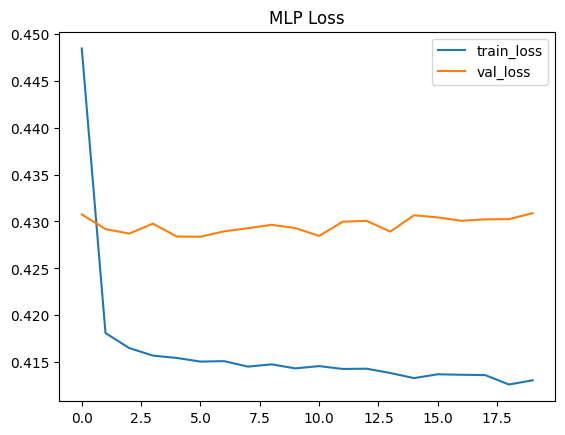

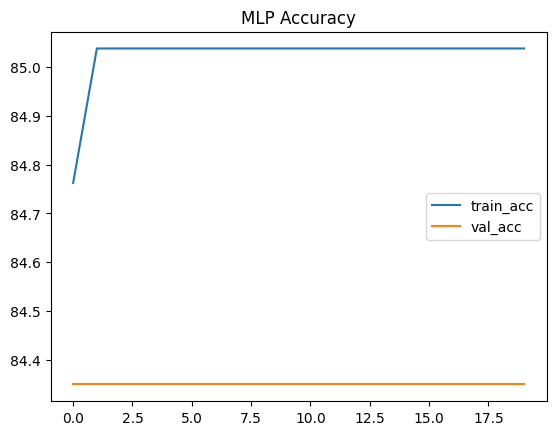

In [100]:


plot(train_losses, val_losses, train_accs, val_accs, "MLP")

In [101]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    mlp_pred = logits.argmax(dim=1).cpu().numpy()
    mlp_probs = logits.softmax(dim=1)[:,1].cpu().numpy()

print("MLP accuracy:", accuracy_score(y_test, mlp_pred))
print("MLP AUC:", roc_auc_score(y_test, mlp_probs))


MLP accuracy: 0.8435
MLP AUC: 0.5866767292071867


In [102]:
def fairness_by_group(y_true, y_pred, groups):
    results = {}
    for g in sorted(groups.unique()):
        mask = (groups == g)
        tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask], labels=[0,1]).ravel()
        results[g] = {
            "FPR": fp/(fp+tn) if (fp+tn)>0 else np.nan,
            "FNR": fn/(fn+tp) if (fn+tp)>0 else np.nan,
            "TPR": tp/(tp+fn) if (tp+fn)>0 else np.nan,
            "TNR": tn/(tn+fp) if (tn+fp)>0 else np.nan,
        }
    return pd.DataFrame(results).T

race_test   = df.loc[X_test.index, "race"]
gender_test = df.loc[X_test.index, "gender"]

print("\n=== MLP Fairness by Race ===")
print(fairness_by_group(y_test, mlp_pred, race_test))

print("\n=== MLP Fairness by Gender ===")
print(fairness_by_group(y_test, mlp_pred, gender_test))



=== MLP Fairness by Race ===
   FPR  FNR  TPR  TNR
0  0.0  1.0  0.0  1.0
1  0.0  1.0  0.0  1.0
2  0.0  1.0  0.0  1.0

=== MLP Fairness by Gender ===
   FPR  FNR  TPR  TNR
0  0.0  1.0  0.0  1.0
1  0.0  1.0  0.0  1.0


In [106]:
mlp_pred_adj = (mlp_probs > 0.30).astype(int)

print(fairness_by_group(y_test, mlp_pred_adj, race_test))
print(fairness_by_group(y_test, mlp_pred_adj, gender_test))


        FPR       FNR       TPR       TNR
0  0.019627  0.966480  0.033520  0.980373
1  0.034483  0.987013  0.012987  0.965517
2  0.007634  0.982456  0.017544  0.992366
        FPR       FNR       TPR       TNR
0  0.026152  0.983607  0.016393  0.973848
1  0.016968  0.961538  0.038462  0.983032
